In [92]:
####################################
#ENVIRONMENT SETUP

In [93]:
#LIBRARIES

#system
import os
import sys

#math and array operations
import numpy as np
import math
import pandas as pd

#data classes
import xarray as xr
import pickle

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#loading bar
from tqdm import tqdm

#datetime
from datetime import datetime

In [94]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [225]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data")
dataType = "RadarComparison"
# dataType = "RadarComparison_Interpolation" #*TESTING

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP/RadarComparison



In [243]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [244]:
#Setup

Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

In [245]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = (Region,Case,"TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 241/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2022-06-05_12.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs/diag_cartesian/diag.2022-06-05_12.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         PRECIP
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-05 to 2022-06-08
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:241
 # Diag Files:   241
 # Time Steps:   241
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs
 Static File:    PRECIP_regional5500_scale

In [246]:
#Importing ERA5 Data Loading Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","ERA5_Data"))
from CLASSES_ERA5DataLoading import ERA5DataLoading_Class,ERA5DataLoading_Class_gdex

In [247]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [248]:
###############
#JOB ARRAY SETUP

In [249]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_JobArray import JobArray_Class

In [250]:
#JOB ARRAY SETUP
UsingJobArray=True

def GetNumJobs():
    num_jobs=20
    return num_jobs

num_jobs = GetNumJobs()
JobArray = JobArray_Class(total_elements=ModelData_NSSL.Ntime, num_jobs=num_jobs, UsingJobArray=UsingJobArray)
start_job = JobArray.start_job; end_job = JobArray.end_job

def GetLoopElements(start_job,end_job):
    loop_elements = np.arange(ModelData_NSSL.Ntime)[start_job:end_job].tolist()
    return loop_elements
loop_elements = GetLoopElements(start_job,end_job)

Running timesteps from 0:12 



In [251]:
########################
#DATA INFORMATION

In [252]:
#DATA CITATION

# PRECIP (https://www.eol.ucar.edu/field_projects/precip)
# Prediction of Rainfall Extremes Campaign in the Pacific

# PROJECT DATES
# 05/25/2022 - 08/10/2022
# Project Location
# Taiwan

# SPOL Radar https://www.eol.ucar.edu/observing_facilities/s-pol

In [253]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_PRECIP_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [254]:
#LOADING RADAR CLASS
import xesmf as xe

folderDirectory = os.path.join(
    DirectoryManager.dataDirectory,
    "Observation_Data/PRECIP/Radar",
    ModelData_NSSL.case
)

RadarData_PRECIP = RadarData_PRECIP_Class(ModelData_NSSL, folderDirectory)

Target time:  2022-06-05 12:00:00
Closest file: ncf_20220605_134445.nc (2022-06-05 13:44:45)


In [255]:
##########################
#DATA LOADING FUNCTIONS

In [256]:
#Converting timeStrings
def ConvertTimeStringtoDateTime(timeString):
    """
    Converts a time string like '2022-06-30_00.00.00' to a datetime object.
    """
    return datetime.strptime(timeString, '%Y-%m-%d_%H.%M.%S')
def ConvertTimeStringtoTimeTitle(timeString):
    """
    Converts a time string like '2022-06-30_00.00.00' to a datetime object.
    Formatted for use as a plot title.
    """
    # Parse the custom format to a datetime object
    dt = datetime.strptime(timeString, '%Y-%m-%d_%H.%M.%S')
    # Format it to 'YYYY-MM-DD HH:MM:SS'
    return dt.strftime('%Y-%m-%d %H:%M:%S')

In [257]:
RadarDataMask = RadarObservationMask_Class.LoadMaskData(DirectoryManager, ModelData_NSSL)

Loaded mask: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RadarData/RadarObservationMask/PRECIP_WET_spinup12hrs/RadarObservationMask.nc



In [258]:
def FixLatLon_RadarData(radarData):        
    radarData = radarData.isel(latitude=slice(None, None, -1))

    radarData = radarData.assign_coords(
        longitude=((radarData.longitude + 180) % 360) - 180
    )
    return radarData

def ReturnLatLon_RadarData(radarData):
    # Fix latitude order
    radarData_fixed = radarData.isel(latitude=slice(None, None, -1))

    # Fix longitude convention
    radarData_fixed = radarData_fixed.assign_coords(
        longitude=radarData.longitude+360
    )

    return radarData_fixed

def InterpolateRadarData(radarData,modelData):
    radarData = FixLatLon_RadarData(radarData)
    
    radarData_PRECIP = radarData.interp(
        latitude=modelData.latitude,
        longitude=modelData.longitude,
        method="linear"
    )
    return radarData_PRECIP

In [259]:
## GetData

zGrid_f, zGrid_c = ModelData_NSSL.GetZGrids() #*TESTING
[zTarget_f, zTarget_c] = ModelData_NSSL.GetZTarget(zGrid_f, zGrid_c) #*TESTING

z_levels_filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
zlevels = np.loadtxt(z_levels_filePath)/1e3
zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
zlevels = zTarget_f #*TESTING
zlevels_center = zTarget_c #*TESTING

def GetData(t):
    timeString = ModelData_NSSL.timeStrings[t]
    timeString_datetime = ConvertTimeStringtoDateTime(timeString)
    
    #Loading Model Radar
    modelRadarData_NSSL = ModelData_NSSL.GetDataTimestep_diag(t)["refl10cm"]
    modelRadarData_TEMPO = ModelData_TEMPO.GetDataTimestep_diag(t)["refl10cm"]
    modelRadarTimeTitle = ConvertTimeStringtoTimeTitle(timeString)

    # #Interpolating Z levels #*TESTING
    # #################################
    # modelRadarData_NSSL = ModelData_NSSL.InterpolateVertical(modelRadarData_NSSL,zGrid_f,zGrid_c,zTarget_f,zTarget_c)
    # modelRadarData_TEMPO = ModelData_TEMPO.InterpolateVertical(modelRadarData_TEMPO,zGrid_f,zGrid_c,zTarget_f,zTarget_c)
    # #################################
    
    #Loading Observational Radar
    radarData_PRECIP,_ = RadarData_PRECIP.GetData_AllZLevels(DirectoryManager,ModelData_NSSL, t)
    radarData_PRECIP = RadarData_PRECIP.InterpolateRadarData3D(radarData_PRECIP, ModelData_NSSL, DirectoryManager) #interpolation in t/z

    # Applying RadarDataMask
    modelRadarData_NSSL = modelRadarData_NSSL.where(RadarDataMask == True)
    modelRadarData_TEMPO = modelRadarData_TEMPO.where(RadarDataMask == True)
    # radarData_PRECIP = radarData_PRECIP.where(RadarDataMask == True) #crashes kernal since x!=longitude, not necessary, already applied to model

    # Assign height to MPAS reflectivity grid
    modelRadarData_NSSL = modelRadarData_NSSL.assign_coords(
        nVertLevels=("nVertLevels", zlevels_center) 
    )
    # Assign height to MPAS reflectivity grid
    modelRadarData_TEMPO= modelRadarData_TEMPO.assign_coords(
        nVertLevels=("nVertLevels", zlevels_center) 
    )
    # Interpolate to PRECIP height grid
    modelRadarData_NSSL = modelRadarData_NSSL.interp(
        nVertLevels=radarData_PRECIP.z.data
    )
    # Interpolate to PRECIP height grid
    modelRadarData_TEMPO = modelRadarData_TEMPO.interp(
        nVertLevels=radarData_PRECIP.z.data
    )

    modelRadarData_NSSL = modelRadarData_NSSL.where(modelRadarData_NSSL>0)
    modelRadarData_TEMPO = modelRadarData_TEMPO.where(modelRadarData_TEMPO>0)
    radarData_PRECIP = radarData_PRECIP.where(radarData_PRECIP>0)
    
    return (modelRadarData_NSSL,modelRadarData_TEMPO,radarData_PRECIP)

In [260]:
##########################
#CALCULATING FUNCTIONS

In [261]:
## CalculateFSS_scores

# Leeuwenburg, T., Loveday, N., Ebert, E. E., Cook, H., Khanarmuei, M., Taggart, R. J., Ramanathan, N., Carroll, M., Chong, S., Griffiths, A., & Sharples, J. (2024). 
# scores: A Python package for verifying and evaluating models and predictions with xarray. Journal of Open Source Software, 9(99), 6889. https://doi.org/10.21105/joss.06889
# https://scores.readthedocs.io/en/2.0.0/tutorials/Fractions_Skill_Score.html

# pip install scores
from scores.spatial import fss_2d_single_field
from scores.fast.fss.typing import FssComputeMethod

def CalculateFSS_scores(forecast,observation,threshold,window_size):
    compute_method = FssComputeMethod.NUMPY
    threshold_operator = np.greater_equal
    # threshold_operator = np.greater
    
    fs_score = fss_2d_single_field(
        forecast,
        observation,
        event_threshold=threshold,
        window_size=window_size,           # same interpretation as 'scale'
        threshold_operator=threshold_operator,
        compute_method=compute_method # default and fastest
    )
    return fs_score*100

In [262]:
## Run_FSS

scale=5
def Run_FSS(forecast,observation, thresholds=[0,20,40,65], printstatement=False):
    #scale: nxn pixels
    fs_scores = []
    for threshold in thresholds:
        # fs_score = CalculateFSS_pysteps(forecast=forecast,observation=observation,threshold=threshold,scale=scale)
        # if printstatement==True:
            # print(f"FSS = {fs_score:.2f}% for threshold = {threshold} dBZ")
        
        fs_score = CalculateFSS_scores(forecast=forecast,observation=observation,threshold=threshold,window_size=(scale,scale))
        if printstatement==True:
            print(f"FSS = {fs_score:.2f}% for threshold = {threshold} dBZ")
        fs_scores.append(fs_score)
    return fs_scores, thresholds

In [263]:
##########################
#LOADING DATA
running = True #keep true when using job array
running = False

In [264]:
##########################
#CALCULATING FOR ALL TIMESTEPS

In [265]:
def GetFilePath(ModelData, t):
    """
    Build the FSS filename using ModelData and load the .pkl file.
    Creates output directory if needed.
    Returns (fullFilePath, loadedData or None).
    """

    # Build file name
    fileName = (
        f"FractionSkillScore_3D_{ModelData.region}_"
        f"{ModelData.case}_spinup{ModelData.spinup_hours}hrs_{ModelData.timeStrings[t]}.pkl"
    )

    # Build directory for FSS output
    outputDir = os.path.join(
        DirectoryManager.GetOutputDirectory(codeType, dataType),
        "FractionSkillScore",
        f"{ModelData.region}_{ModelData.case}_spinup{ModelData.spinup_hours}hrs",
    )
    os.makedirs(outputDir, exist_ok=True)

    # Full path to the .pkl file
    fullFilePath = os.path.join(outputDir, fileName)

    # No cached file found
    return fullFilePath


In [266]:
## RunCode

def RunCode():

    for t in tqdm(loop_elements):
        fullFilePath = GetFilePath(ModelData_NSSL, t)
    
        modelRadarData_NSSL, modelRadarData_TEMPO, radarData_PRECIP = GetData(t)
    
        # Per-height storage
        fss_levels_NSSL = []
        fss_levels_TEMPO = []
        
        nz = radarData_PRECIP.sizes["z"]    
        for k in range(nz):
            forecast_1 = modelRadarData_NSSL.isel(nVertLevels=k).data
            forecast_2 = modelRadarData_TEMPO.isel(nVertLevels=k).data
            observation = radarData_PRECIP.isel(z=k).data
    
            fs1, thresholds = Run_FSS(forecast_1, observation, printstatement=False)
            fs2, _ = Run_FSS(forecast_2, observation, printstatement=False)
    
            fss_levels_NSSL.append(fs1)
            fss_levels_TEMPO.append(fs2)

        # -------------------------------------------------------
        # 3. Save newly computed FSS results
        # -------------------------------------------------------
        data_to_save = {
            "FSS_NSSL":  np.array(fss_levels_NSSL),
            "FSS_TEMPO": np.array(fss_levels_TEMPO),
            "thresholds": thresholds,
            "zlevels": modelRadarData_NSSL.nVertLevels,
            "timestep": t,
        }
        with open(fullFilePath, "wb") as f:
            pickle.dump(data_to_save, f)

In [267]:
if running:
    RunCode()

In [268]:
####################################
#RECOMBINING
recombining = False #keep false when job_array is running
recombining = True

In [269]:
def Recombine():
    """
    Recombine per-timestep FSS pickle files into full time series.
    """

    FSS_NSSL_all  = []
    FSS_TEMPO_all = []

    thresholds = None
    zlevels    = None

    for t in tqdm(range(ModelData_NSSL.Ntime), desc="Recombining FSS"):

        filePath = GetFilePath(ModelData_NSSL, t)

        # Skip missing timesteps (important for job arrays)
        if not os.path.exists(filePath):
            continue

        with open(filePath, "rb") as f:
            data = pickle.load(f)

        FSS_NSSL_all.append(data["FSS_NSSL"])
        FSS_TEMPO_all.append(data["FSS_TEMPO"])

        # Store metadata once
        if thresholds is None:
            thresholds = data["thresholds"]
            zlevels    = data["zlevels"]

    scores_array_NSSL  = np.array(FSS_NSSL_all)
    scores_array_TEMPO = np.array(FSS_TEMPO_all)

    return scores_array_NSSL,scores_array_TEMPO,thresholds,zlevels

In [280]:
if recombining:
    [scores_array_NSSL_tz,scores_array_TEMPO_tz,thresholds,zlevels] = Recombine()

Recombining FSS: 100%|██████████| 241/241 [00:00<00:00, 5664.64it/s]


In [281]:
####################################
#PLOTTING FUNCTIONS
plotting = False #keep false when running job array
plotting = True

In [282]:
#HELPER FUNCTIONS
def SetXLimitsDatetime(ax, time_array):
    """
    Ensures datetime x-axis starts and ends exactly at the first and last time values.
    Works for both datetime.datetime and np.datetime64 arrays.
    """
    # Convert to Matplotlib’s internal float format if needed
    times = np.asarray(time_array)
    if np.issubdtype(times.dtype, np.datetime64):
        times = date2num(times)
    elif isinstance(times[0], (object,)):
        try:
            times = date2num(times)
        except Exception:
            pass

    ax.set_xlim(times.min(), times.max())

In [283]:
def MakeFSSPlot(scores_array_NSSL, scores_array_TEMPO, thresholds):
    """
    Plot FSS time series for NSSL (solid) and TEMPO (dashed)
    with two legends: thresholds and model line styles.
    """

    #time axis
    time_strings = ModelData_NSSL.timeStrings
    times = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in time_strings]

    # Colors for thresholds
    colors = [
        "black",   # threshold 0
        "blue",    # threshold 1
        "purple",  # threshold 2
        "red",     # threshold 3
    ]

    # Create figure & axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # ------------------------------------------------------
    # Plotting lines
    # ------------------------------------------------------
    for i in range(scores_array_NSSL.shape[1]):
        ax.plot(
            times,
            scores_array_NSSL[:, i],
            linestyle='solid',
            color=colors[i],
            label=f">= {thresholds[i]} dBZ"
        )

        ax.plot(
            times,
            scores_array_TEMPO[:, i],
            linestyle='dashed',
            color=colors[i]
        )

    # Axis limits (flush last tick to edge)
    ax.set_xlim(0, ModelData_NSSL.Ntime - 1)
    ax.set_ylim(bottom=0)

    # ------------------------------------------------------
    # Legend 1: Threshold colors (left)
    # ------------------------------------------------------
    threshold_legend = [
        Line2D(
            [0], [0],
            color=colors[i],
            linestyle='solid',
            linewidth=2,
            label=f">= {thresholds[i]} dBZ"
        )
        for i in range(len(thresholds))
    ]

    leg1 = ax.legend(
        handles=threshold_legend,
        title="Thresholds",
        loc="upper left"
    )

    # ------------------------------------------------------
    # Legend 2: Model styles (top center)
    # ------------------------------------------------------
    model_legend = [
        Line2D([0], [0], color="black", linestyle='solid', linewidth=2, label="NSSL"),
        Line2D([0], [0], color="black", linestyle='dashed', linewidth=2, label="TEMPO"),
    ]

    leg2 = ax.legend(
        handles=model_legend,
        title=f"{ModelData_NSSL.region} {ModelData_NSSL.case}",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=2,
        frameon=False
    )

    # Add first legend back so both show
    ax.add_artist(leg1)

    # ------------------------------------------------------
    # Labels, grid, title
    # ------------------------------------------------------
    # ax.set_xlabel("Time") 
    ax.set_ylabel("FSS (%)")
    ax.set_title(f"Plot of Fraction Skill Score: window = ({scale},{scale})")
    ax.grid(True)
    SetXLimitsDatetime(ax, time_array=times)

    return fig

In [284]:
def GetOutputFile(ModelData_1,ModelData_2, outputPlottingDirectory):
    outputSubDirectory = f"{ModelData_1.region}_{ModelData_1.case}_{ModelData_1.spinup_hours}hrs"
    
    outputFilePath = os.path.join(
        outputPlottingDirectory,
        "FractionSkillScore",
        outputSubDirectory)
    os.makedirs(outputFilePath, exist_ok=True)
    return outputFilePath

def SaveFigure(fig, ModelData_1,ModelData_2):
    """
    Saves a figure to corresponding directory.
    """
    # --- Define output subdirectory and file path ---
    outputFilePath = GetOutputFile(ModelData_1,ModelData_2, outputPlottingDirectory)
    outputFile = os.path.join(outputFilePath,f"FractionSkillScore_3D_{ModelData_1.mpType}vsPRECIPvs{ModelData_2.mpType}.png")

    # --- Save figure ---
    fig.savefig(outputFile, dpi=100, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved to {outputFile}")

In [289]:
#Removing Levels Above maxZLevel km from Timeseries Averages

maxZLevel = 16
def SubsetAltitude(scores_array,
                   maxZLevel=16):

    scores_array[:,np.where(zlevels_center>maxZLevel)[0][0]+1:] = np.nan
    return scores_array

if plotting:
    scores_array_NSSL_tz = SubsetAltitude(scores_array_NSSL_tz, maxZLevel)
    scores_array_TEMPO_tz = SubsetAltitude(scores_array_TEMPO_tz, maxZLevel)

In [290]:
##########################
#PLOTTING

In [291]:
if plotting:
    scores_array_NSSL = np.nanmean(scores_array_NSSL_tz,axis=1)
    scores_array_TEMPO = np.nanmean(scores_array_TEMPO_tz,axis=1)

In [292]:
if plotting:
    fig = MakeFSSPlot(scores_array_NSSL, scores_array_TEMPO, thresholds)
    SaveFigure(fig, ModelData_NSSL, ModelData_TEMPO)

Saved to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/Observation_Data/RadarComparison_Interpolation/FractionSkillScore/PRECIP_WET_12hrs/FractionSkillScore_3D_NSSLvsPRECIPvsTEMPO.png


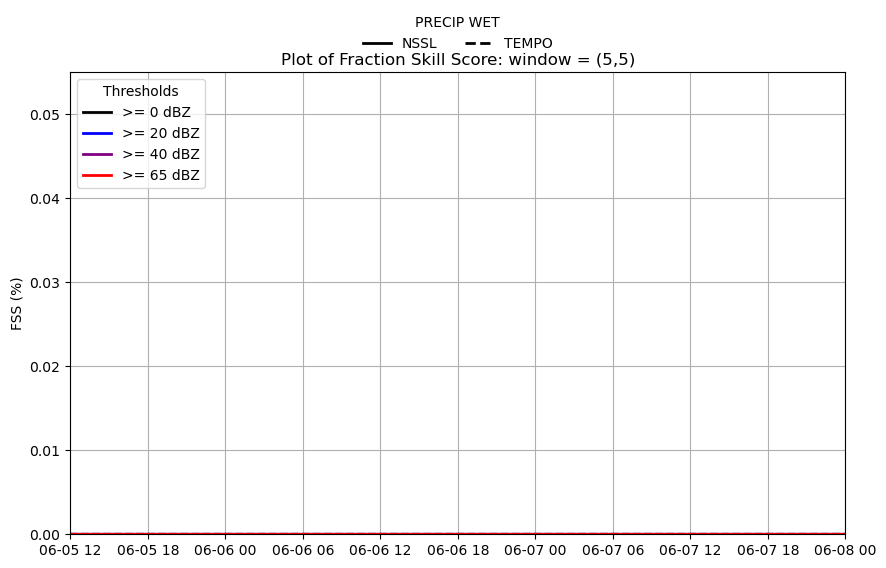

In [293]:
fig

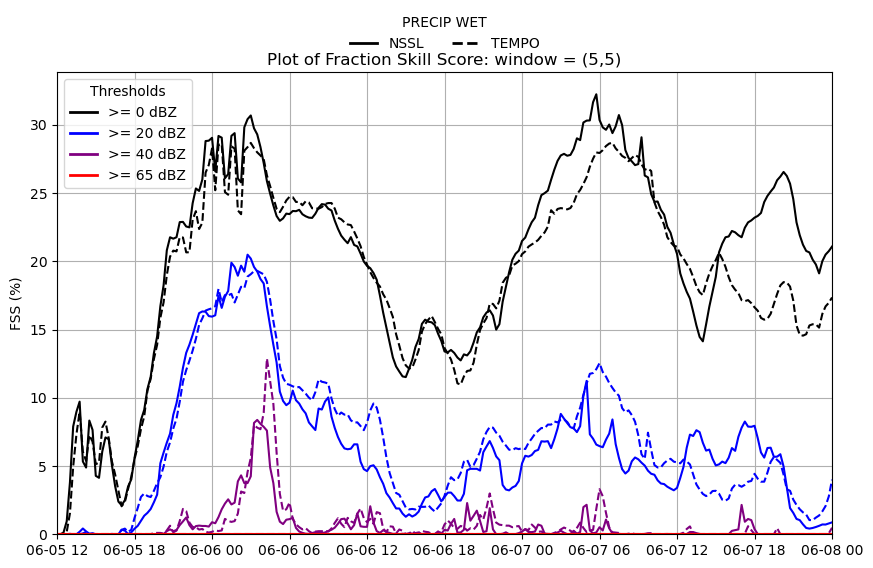

In [224]:
fig

In [ ]:
#####################
#TESTING

In [ ]:
# from matplotlib.colors import TwoSlopeNorm

# fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# cf0 = axes[0].contourf(scores_array_NSSL_tz[:, :, 0].T)
# axes[0].set_title("NSSL")
# fig.colorbar(cf0, ax=axes[0])

# cf1 = axes[1].contourf(scores_array_TEMPO_tz[:, :, 0].T)
# axes[1].set_title("TEMPO")
# fig.colorbar(cf1, ax=axes[1])

# diff = scores_array_NSSL_tz[:, :, 0] - scores_array_TEMPO_tz[:, :, 0]
# norm = TwoSlopeNorm(vcenter=0.0, vmin=np.nanmin(diff), vmax=np.nanmax(diff))

# cf2 = axes[2].contourf(diff.T, cmap="RdBu_r", norm=norm)
# axes[2].set_title("NSSL − TEMPO")
# fig.colorbar(cf2, ax=axes[2])

# plt.tight_layout()
# plt.show()
